# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


In [1]:
!kaggle datasets download -d parulpandey/palmer-archipelago-antarctica-penguin-data
!unzip -q palmer-archipelago-antarctica-penguin-data.zip -d dataset

print("✅ Dataset berhasil didownload dan diekstrak!")

Dataset URL: https://www.kaggle.com/datasets/parulpandey/palmer-archipelago-antarctica-penguin-data
License(s): CC0-1.0
100% 11.3k/11.3k [00:00<00:00, 18.6MB/s]

✅ Dataset berhasil didownload dan diekstrak!


# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [2]:
#Type your code here
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [3]:
#Type your code here

# Load dataset
df = pd.read_csv('dataset/penguins_size.csv')

# Tampilkan informasi awal
print("Shape:", df.shape)
print("\nInfo:")
df.info()
print("\nHead:")
df.head()
print("\nDescribe:")
df.describe()

Shape: (344, 7)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   culmen_length_mm   342 non-null    float64
 3   culmen_depth_mm    342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                334 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB

Head:

Describe:


,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

Missing Values:
species               0
island                0
culmen_length_mm      2
culmen_depth_mm       2
flipper_length_mm     2
body_mass_g           2
sex                  10
dtype: int64

Total missing: 18

Jumlah duplikat: 0

Distribusi target:
species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64


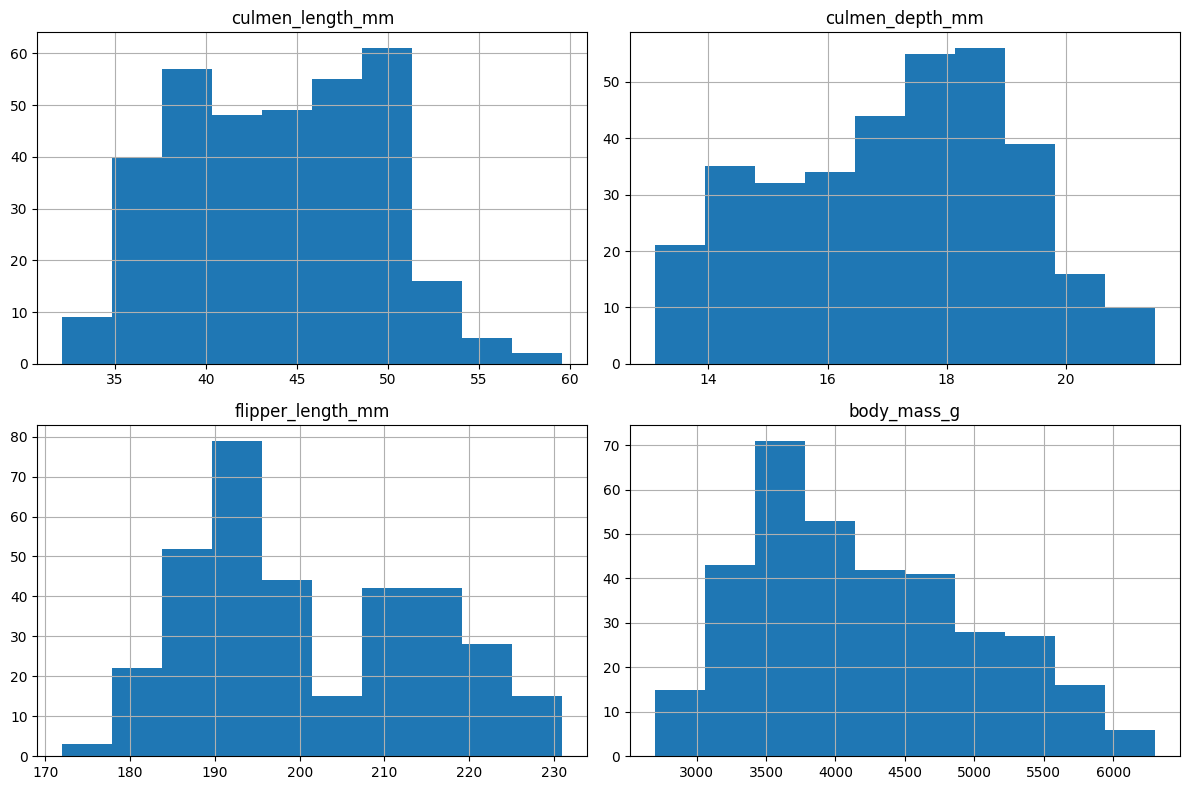

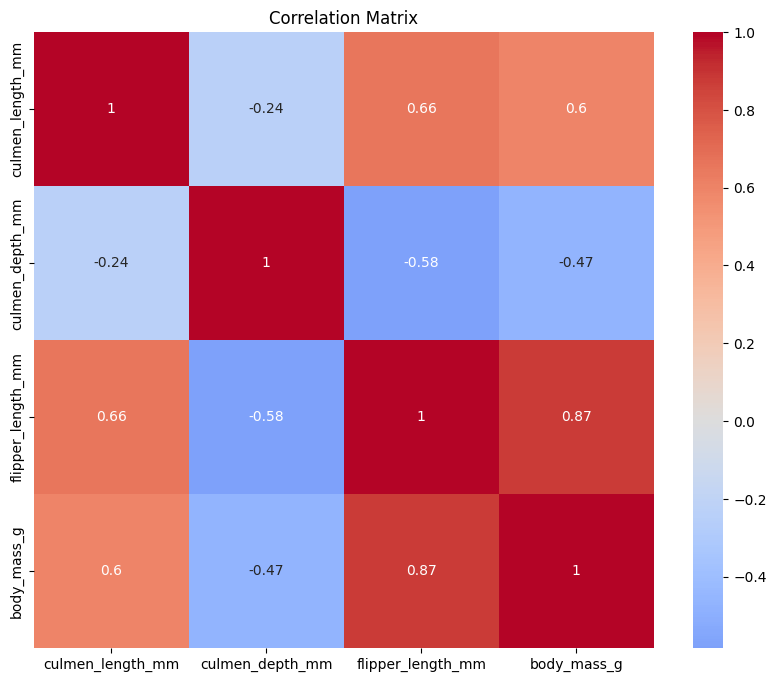

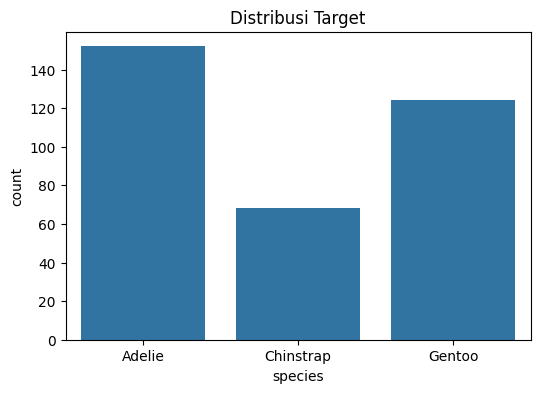

In [4]:
#Type your code here
# ===== Cek Missing Values =====
print("Missing Values:")
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()}")

# ===== Cek Duplikat =====
print(f"\nJumlah duplikat: {df.duplicated().sum()}")

# ===== Distribusi Target =====
print("\nDistribusi target:")
print(df['species'].value_counts())

# ===== Visualisasi =====
# Histogram semua fitur numerik
df.hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

# Heatmap korelasi
plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(),
            annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.show()

# Countplot untuk kolom target (jika klasifikasi)
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='species')
plt.title('Distribusi Target')
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import os

# ===== Handle Missing Values =====
# Palmer Penguins memiliki beberapa baris bernilai null (misal kolom sex kosong), kita drop saja
df = df.dropna()

# ===== Handle Duplikat =====
df = df.drop_duplicates()

# ===== Encode Categorical Variables =====
# Kolom 'island' dan 'sex' berisi teks, kita harus encode ke angka
le_island = LabelEncoder()
df['island'] = le_island.fit_transform(df['island'])

le_sex = LabelEncoder()
df['sex'] = le_sex.fit_transform(df['sex'])

# Target 'species' juga bertipe string (Adelie, Chinstrap, Gentoo), kita encode ke angka
le_species = LabelEncoder()
df['species'] = le_species.fit_transform(df['species'])

# ===== Pisahkan Fitur dan Target =====
X = df.drop('species', axis=1)
y = df['species']

# ===== Split Data =====
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train size: {X_train.shape}")
print(f"Test size: {X_test.shape}")

# ===== Scaling (opsional tapi recommended) =====
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ===== Simpan data yang sudah dipreprocess =====
# BUAT FOLDER JIKA BELUM ADA
os.makedirs('dataset_preprocessing', exist_ok=True)

# Gabungkan kembali untuk disimpan (gunakan nama kolom asli dari X)
train_data = pd.DataFrame(X_train_scaled, columns=X.columns)
train_data['target'] = y_train.values
train_data.to_csv('dataset_preprocessing/train.csv', index=False)

test_data = pd.DataFrame(X_test_scaled, columns=X.columns)
test_data['target'] = y_test.values
test_data.to_csv('dataset_preprocessing/test.csv', index=False)

print("Data preprocessing selesai dan tersimpan!")


Train size: (267, 6)
Test size: (67, 6)
Data preprocessing selesai dan tersimpan!
